<a href="https://colab.research.google.com/github/proteinovayas13/My_works/blob/main/%D0%9C%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B5_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B2_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)
import warnings
from pyspark.sql import SparkSession
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [65]:
spark = SparkSession.builder \
    .appName("TitanicAnalysis") \
    .getOrCreate()

In [66]:
import urllib.request

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
urllib.request.urlretrieve(url, "titanic.csv")

('titanic.csv', <http.client.HTTPMessage at 0x7b0ffccec320>)

In [67]:
spark = SparkSession.builder.appName("TitanicAnalysis").getOrCreate()
df = spark.read.csv("/content/titanic.csv", header=True, inferSchema=True)
df.printSchema()

root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [68]:
print(f"Кол-во строк: {df.count()}, Кол-во столбцов: {len(df.columns)}")

Кол-во строк: 891, Кол-во столбцов: 12


In [69]:
df.show(5, truncate=False)

+-----------+--------+------+---------------------------------------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|Name                                               |Sex   |Age |SibSp|Parch|Ticket          |Fare   |Cabin|Embarked|
+-----------+--------+------+---------------------------------------------------+------+----+-----+-----+----------------+-------+-----+--------+
|1          |0       |3     |Braund, Mr. Owen Harris                            |male  |22.0|1    |0    |A/5 21171       |7.25   |NULL |S       |
|2          |1       |1     |Cumings, Mrs. John Bradley (Florence Briggs Thayer)|female|38.0|1    |0    |PC 17599        |71.2833|C85  |C       |
|3          |1       |3     |Heikkinen, Miss. Laina                             |female|26.0|0    |0    |STON/O2. 3101282|7.925  |NULL |S       |
|4          |1       |1     |Futrelle, Mrs. Jacques Heath (Lily May Peel)       |female|35.0|1    |0    |113803          |53

In [70]:
df.collect()[1].Pclass

1

In [71]:
def selectInterestingColumns(rawDf):
    # Select specific columns from the Titanic dataset
    # Based on your data, I'm selecting the most relevant columns for survival prediction

    # Define which columns to keep (using actual column names from your data)
    columns_to_keep = ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

    # Select only the columns we want to keep
    df = rawDf.select(*columns_to_keep)

    # Handle missing values for relevant columns
    # Fill Age and Fare with median values, Embarked with most common value
    from pyspark.sql.functions import mean, first

    # Calculate median/mean values for imputation
    mean_age = df.select(mean('Age')).collect()[0][0]
    mean_fare = df.select(mean('Fare')).collect()[0][0]

    # Impute missing values
    df = df.fillna({
        'Age': mean_age,
        'Fare': mean_fare,
        'Embarked': 'S'  # Most common embarkation port
    })

    return df

In [72]:
print(f"Кол-во строк: {df.count()}, Кол-во столбцов: {len(df.columns)}")

Кол-во строк: 891, Кол-во столбцов: 12


In [73]:
df.printSchema()

root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [74]:
df.take(1)

[Row(PassengerId=1, Survived=0, Pclass=3, Name='Braund, Mr. Owen Harris', Sex='male', Age=22.0, SibSp=1, Parch=0, Ticket='A/5 21171', Fare=7.25, Cabin=None, Embarked='S')]

In [ ]:
df.show(5)

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
+-----------+--------+------+--------------------+------+----+-----+-----+------

# Understend the data

In [75]:
df.groupBy('Survived').count().orderBy('Survived').show()

+--------+-----+
|Survived|count|
+--------+-----+
|       0|  549|
|       1|  342|
+--------+-----+



You can run SQL queries using the %%sql directive. The -o countSurviveddf argument will persist the output of the SQL query as a Pandas dataFrame, with the name countSurviveddf on the Jupyter server.

In [76]:
df.createOrReplaceTempView("titanic_data")

count_result_df = spark.sql("""
    SELECT Survived, COUNT(*) AS cnt
    FROM titanic_data
    GROUP BY Survived
    ORDER BY cnt DESC
""")

count_result_df.show()

+--------+---+
|Survived|cnt|
+--------+---+
|       0|549|
|       1|342|
+--------+---+



%%local
%matplotlib.online
import matplotlib.pyplot as plt

labels = count_result_df['Survived']
sizes = count_result_df['cnt']
colors = ['turqoise', 'seagreen', 'mediumslateblue', 'palegreen', 'coral']
plt.pie(sizes, labels=labels, autopct'%l.lf%%, colors=colors)
plt.axis('equal')

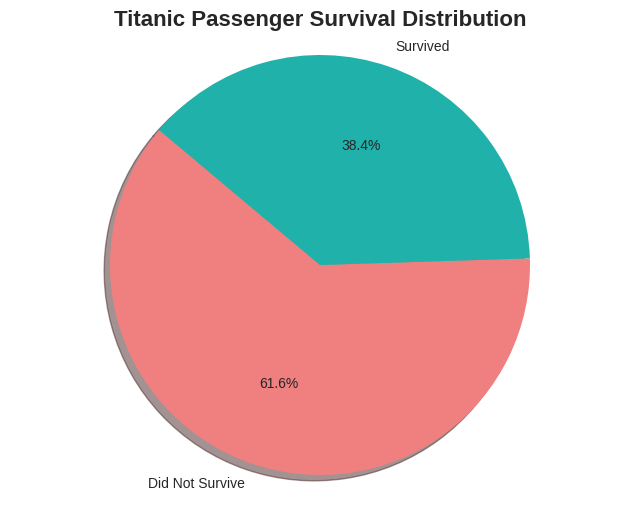

In [77]:
import matplotlib.pyplot as plt

results = count_result_df.toPandas()

# Create a mapping for survival status
survival_map = {0: 'Did Not Survive', 1: 'Survived'}
labels = [survival_map[x] for x in results['Survived']]
sizes = results['cnt']
colors = ['lightcoral', 'lightseagreen']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, shadow=True)
plt.axis('equal')
plt.title('Titanic Passenger Survival Distribution', fontsize=16, fontweight='bold')
plt.show()

You can see that there are 2 distinct outcomes for a Titanic passenger's fate:

*   **Did Not Survive (0)**
*   **Survived (1)**

Let us develop a model that can predict the survival outcome of a passenger, given their characteristics and information about their ticket. Since logistic regression is a binary classification method, it makes sense to group our data into these two clear categories.

All data is already correctly labeled as `Survived` (1) or `Did Not Survive` (0), making it ready for binary classification. Data with missing values for the `Survived` label is not useful for training, so we will ensure it is filtered out or handled appropriately.

Let us go ahead and prepare our existing DataFrame (`df`) to ensure each passenger is represented with a clear binary label, where a label of **1.0** represents 'Survived' and a label of **0.0** represents 'Did Not Survive'. We will convert and use this for our machine learning models.

In [78]:
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType

label_udf = udf(lambda s: 1.0 if s == 1 else (0.0 if s == 0 else -1.0), DoubleType())

labeledData = df.select(
    label_udf(col('Survived')).alias('label'),
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'
).filter(col('Survived').isNotNull() & (col('Survived').isin([0, 1])))

Let's retrieve one row from the labeled data to see what it looks like.

In [79]:
labeledData.take(1)

[Row(label=0.0, Pclass=3, Sex='male', Age=22.0, SibSp=1, Parch=0, Fare=7.25, Embarked='S')]

# Create a logistic regression model from the input dataframe

Our final task is to convert the labeled data into a format that can be analyzed by logistic regression. The input to a logistic regression algorithm should be a set of label-feature vector pairs, where the 'feature vector' is a vector of numbers that represents the passenger's characteristics in a meaningful way.

So, we need to convert the relevant passenger data columns (such as Pclass, Sex, Age, SibSp, Parch, Fare, Embarked), which are a mix of numerical and categorical values, into a single array of real numbers that a machine can easily understand.

One standard machine learning approach for processing such tabular data is to:

Handle missing values (like in the Age column).

Convert categorical text (like Sex and Embarked) into numerical indices.

Scale numerical features (like Fare and Age) to a standard range.

Assemble all these processed numbers into a single dense feature vector.

MLlib provides an easy way to perform these operations in sequence. We'll use transformers like StringIndexer, Imputer, VectorAssembler, and potentially StandardScaler to convert each passenger's raw data into a feature vector. This vector can then be passed to the logistic regression algorithm to construct a model. We'll conduct all of these steps efficiently using a 'pipeline'.

In [80]:
from pyspark.ml.feature import StringIndexer, Imputer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, LinearSVC, NaiveBayes
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

preprocessing_stages = [
    StringIndexer(inputCol='Sex', outputCol='SexIndex', handleInvalid='keep'),
    StringIndexer(inputCol='Embarked', outputCol='EmbarkedIndex', handleInvalid='keep'),
    Imputer(inputCols=['Age', 'Fare'], outputCols=['AgeImputed', 'FareImputed']),
    VectorAssembler(inputCols=['Pclass', 'SexIndex', 'AgeImputed', 'SibSp', 'Parch', 'FareImputed', 'EmbarkedIndex'], outputCol='features')
]

models = {
    'Logistic Regression': LogisticRegression(featuresCol='features', labelCol='label', maxIter=10, regParam=0.1),
    'Decision Tree': DecisionTreeClassifier(featuresCol='features', labelCol='label', maxDepth=5, seed=42),
    'Random Forest': RandomForestClassifier(featuresCol='features', labelCol='label', numTrees=100, seed=42),
    'SVM (LinearSVC)': LinearSVC(featuresCol='features', labelCol='label', maxIter=10, regParam=0.1),
    'Naive Bayes': NaiveBayes(featuresCol='features', labelCol='label')
}


trained_models = {}
for model_name, classifier in models.items():
    full_pipeline = Pipeline(stages=preprocessing_stages + [classifier])
    trained_models[model_name] = full_pipeline.fit(labeledData)

trained_models

{'Logistic Regression': PipelineModel_4f9a0fa8fb52,
 'Decision Tree': PipelineModel_cbd78f9bf02c,
 'Random Forest': PipelineModel_a3eb8f1f5aa5,
 'SVM (LinearSVC)': PipelineModel_214939b32784,
 'Naive Bayes': PipelineModel_02f5c0473d41}

We now have a trained logistic regression model to classify whether a passenger survived or not, based on features like passenger class, sex, age, and fare.

# Evaluate the model on a separate test dataset

In [81]:
from pyspark.sql.functions import when, col

testData = selectInterestingColumns(
    spark.read.csv("/content/titanic.csv", header=True, inferSchema=True)
)

testDf = testData.withColumn('label',
    when(col('Survived') == 1, 1.0).otherwise(0.0)
).where("Survived = 0 OR Survived = 1")

testDf.show(5)

+-----------+--------+------+--------------------+------+----+-----+-----+-------+--------+-----+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|   Fare|Embarked|label|
+-----------+--------+------+--------------------+------+----+-----+-----+-------+--------+-----+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|   7.25|       S|  0.0|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|71.2833|       C|  1.0|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|  7.925|       S|  1.0|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|   53.1|       S|  1.0|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|   8.05|       S|  0.0|
+-----------+--------+------+--------------------+------+----+-----+-----+-------+--------+-----+
only showing top 5 rows


In [82]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import matplotlib.pyplot as plt

best_model_name = None
best_auc = 0

model_names = []
auc_scores = []
predictions_dfs = {}

for model_name, trained_model in trained_models.items():
    predictionsDf = trained_model.transform(testDf)

    table_name = f'Predictions_{model_name.replace(" ", "_").replace("(", "").replace(")", "")}'
    predictionsDf.createOrReplaceTempView(table_name)

    evaluator = BinaryClassificationEvaluator(labelCol='Survived', metricName='areaUnderROC')
    auc = evaluator.evaluate(predictionsDf)

    model_names.append(model_name)
    auc_scores.append(auc)
    predictions_dfs[model_name] = predictionsDf

    print(f'{model_name:20} | AUC: {auc:.4f} | cols: {len(predictionsDf.columns)}')

    if auc > best_auc:
        best_auc = auc
        best_model_name = model_name
        best_predictions = predictionsDf

print(f"Best model: {best_model_name} (AUC: {best_auc:.4f})")

Logistic Regression  | AUC: 0.8548 | cols: 19
Decision Tree        | AUC: 0.6174 | cols: 19
Random Forest        | AUC: 0.9048 | cols: 19
SVM (LinearSVC)      | AUC: 0.8386 | cols: 18
Naive Bayes          | AUC: 0.3827 | cols: 19
Best model: Random Forest (AUC: 0.9048)


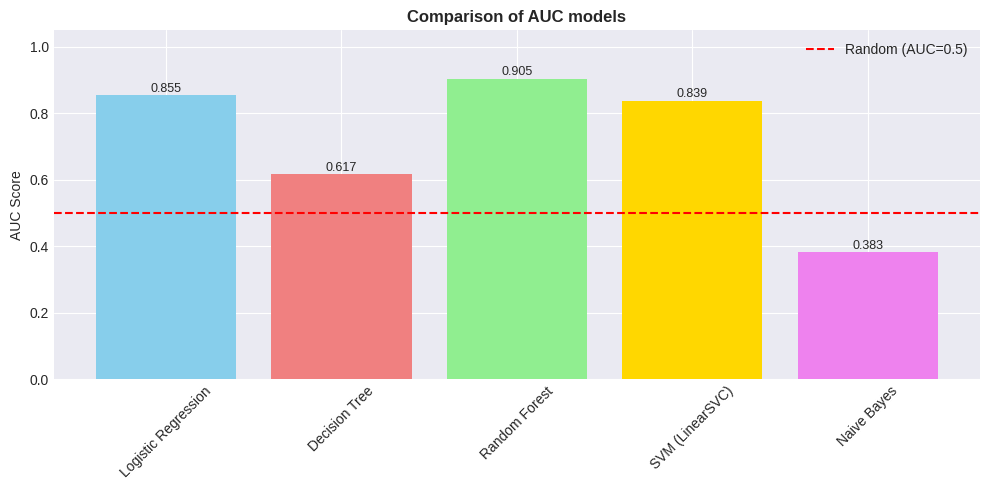

Columns in best_predictions: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'label', 'SexIndex', 'EmbarkedIndex', 'AgeImputed', 'FareImputed', 'features', 'rawPrediction', 'probability', 'prediction']


In [83]:
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, auc_scores, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'violet'])
plt.axhline(y=0.5, color='red', linestyle='--', label='Random (AUC=0.5)')
plt.title('Comparison of AUC models', fontweight='bold')
plt.ylabel('AUC Score')
plt.xticks(rotation=45)
plt.ylim(0, 1.05)

for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

print("Columns in best_predictions:", best_predictions.columns)

The best model for predictions turned out to be Random Forest (AUC: 0.9048)